In [1]:
from pythtb import TBModel, Lattice
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define lattice vectors
lat_vecs = [[1, 0], [1/2, np.sqrt(3)/2]]
# define coordinates of orbitals
orb_vecs = [[1/3, 1/3], [2/3, 2/3]]
lat = Lattice(lat_vecs, orb_vecs, periodic_dirs=[0, 1])

# make two dimensional tight-binding graphene model
my_model = TBModel(lat)

# set model parameters
delta = 0.0
t = -1.0

# set on-site energies
my_model.set_onsite([-delta, delta])
# set hoppings (one for each connected pair of orbitals)
# (amplitude, i, j, [lattice vector to cell containing j])
my_model.set_hop(t, 0, 1, [0, 0])
my_model.set_hop(t, 1, 0, [1, 0])
my_model.set_hop(t, 1, 0, [0, 1])

print(my_model)

----------------------------------------
       Tight-binding model report       
----------------------------------------
r-space dimension           = 2
k-space dimension           = 2
periodic directions         = [0, 1]
number of orbitals          = 2
number of spin components   = 1
number of electronic states = 2

Lattice vectors (Cartesian):
  # 0 ===> [ 1.000,  0.000]
  # 1 ===> [ 0.500,  0.866]
Volume of unit cell (Cartesian) = 0.866 [A^d]

Reciprocal lattice vectors (Cartesian):
  # 0 ===> [ 6.283, -3.628]
  # 1 ===> [ 0.000,  7.255]
Volume of reciprocal unit cell = 45.586 [A^-d]

Orbital vectors (Cartesian):
  # 0 ===> [ 0.500,  0.289]
  # 1 ===> [ 1.000,  0.577]
Orbital vectors (fractional):
  # 0 ===> [ 0.333,  0.333]
  # 1 ===> [ 0.667,  0.667]
No symmetry operations registered.

----------------------------------------
Site energies:
  # 0 ===> -0.000 
  # 1 ===>  0.000 
Hoppings:
  < 0 | H | 1 + [ 0.0 ,  0.0 ] >  ===> -1.0000
  < 1 | H | 0 + [ 1.0 ,  0.0 ] >  ===> -1.000

In [3]:
path = [[0, 0], [2/3, 1/3], [1/2, 1/2], [0, 0]]
label = (r"$\Gamma $", r"$K$", r"$M$", r"$\Gamma $")
nk = 121

k_vec, k_dist, k_node = my_model.k_path(path, nk)

----- k_path report -----
Real-space lattice vectors:
 [[1.      0.     ]
 [0.5     0.86603]]
K-space metric tensor:
 [[ 1.33333 -0.66667]
 [-0.66667  1.33333]]
Nodes (reduced coords):
 [[0.      0.     ]
 [0.66667 0.33333]
 [0.5     0.5    ]
 [0.      0.     ]]
Reciprocal-space vectors:
 [[ 1.      -0.57735]
 [ 0.       1.1547 ]]
Nodes (Cartesian coords):
 [[0.00000e+00 0.00000e+00]
 [6.66667e-01 1.56412e-17]
 [5.00000e-01 2.88675e-01]
 [0.00000e+00 0.00000e+00]]
Segments:
  Node 0 [0. 0.] to Node 1 [0.66667 0.33333]: distance = 0.66667
  Node 1 [0.66667 0.33333] to Node 2 [0.5 0.5]: distance = 0.33333
  Node 2 [0.5 0.5] to Node 3 [0. 0.]: distance = 0.57735
Node distances (cumulative): [0.      0.66667 1.      1.57735]
Node indices in path: [  0  51  76 120]
-------------------------


In [4]:
evals = my_model.solve_ham(k_vec)

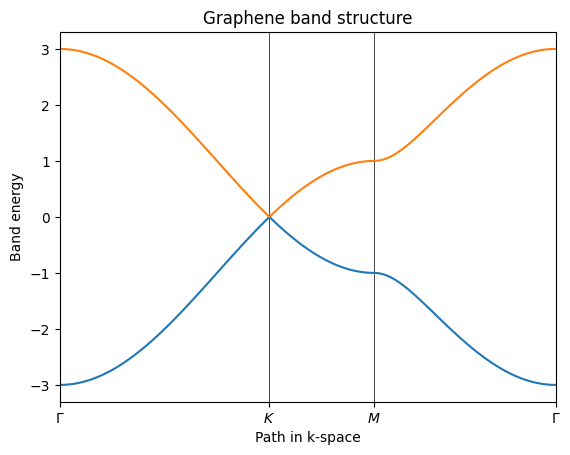

In [5]:
fig, ax = plt.subplots()

ax.set_xlim(k_node[0], k_node[-1])
ax.set_xticks(k_node)
ax.set_xticklabels(label)

for n in range(len(k_node)):
    ax.axvline(x=k_node[n], linewidth=0.5, color="k")
    
ax.set_title("Graphene band structure")
ax.set_xlabel("Path in k-space")
ax.set_ylabel("Band energy")

# plot bands
ax.plot(k_dist, evals)